P-model: gera uma série temporal a partir de um modelo de cascata multiplicativa não-homogenea multifractal.

Input: noValues=4096 (tamanho da série), p deve ser diferente de 0.5000 e representa a distribuição inicial de energia multiplicativa.  p=5 ==> cascata com distribuição homogenea: 50% para cada sub-celula.  Boa faixa de valores para geração de anomalias (flutuações extremas):  0.30 < p < 0.45   e   0.55 < p < 0.95

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import norm
import io
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline

In [ ]:
#XP-model adapted from Meneveau & Sreenevasan, 1987 & Malara et al., 2016
#Valid Ranges for p, based on Didier-Sornette's Theory
#Author: R.R.Rosa, R. Sautter and  N. Joshi
#Version: 1.1
#Date: 23/08/2022

import numpy as np
#import statistics as stat
from matplotlib import pyplot


def pmodel(noValues=1024, p=0.3, slope=[]):
    noOrders = int(np.ceil(np.log2(noValues)))
    noValuesGenerated = 2**noOrders

    dx = np.array([1])
    for n in range(noOrders):
        dx = next_step_1d(dx, p)

    if (slope):
        fourierCoeff = fractal_spectrum_1d(noValues, slope/2)
        meanVal = np.mean(dx)
        stdy = np.std(dx)
        x = np.fft.ifft(dx - meanVal)
        phase = np.angle(x)
        x = fourierCoeff*np.exp(1j*phase)
        x = np.fft.fft(x).real
        x *= stdy/np.std(x)
        x += meanVal
    else:
        x = dx

    return x[0:noValues], dx[0:noValues]


def next_step_1d(dx, p):
    y2 = np.zeros(dx.size*2)
    sign = np.random.rand(1, dx.size) - 0.5
    sign /= np.abs(sign)
    y2[0:2*dx.size:2] = dx + sign*(1-2*p)*dx
    y2[1:2*dx.size+1:2] = dx - sign*(1-2*p)*dx

    return y2


def fractal_spectrum_1d(noValues, slope):
    ori_vector_size = noValues
    ori_half_size = ori_vector_size//2
    a = np.zeros(ori_vector_size)

    for t2 in range(ori_half_size):
        index = t2
        t4 = 1 + ori_vector_size - t2
        if (t4 >= ori_vector_size):
            t4 = t2
        coeff = (index + 1)**slope
        a[t2] = coeff
        a[t4] = coeff

    a[1] = 0

    return a



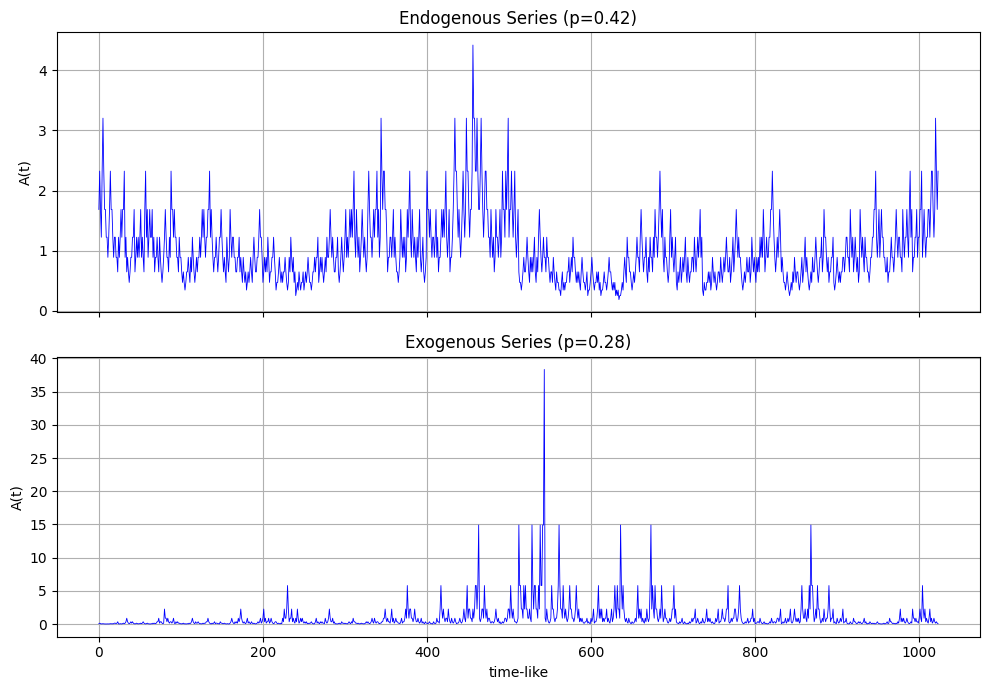

In [ ]:
# Parameters
N = 1024
p_endo = 0.42
p_exo = 0.28

# Generate series
_, dx_endo = pmodel(N, p_endo)
_, dx_exo = pmodel(N, p_exo)

# Add offset to avoid values too close to zero
df_endo = dx_endo + 0.01
df_exo = dx_exo + 0.01

# Plot
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Plot endogenous series (a)
axs[0].plot(df_endo, label=f'Endogenous (p={p_endo}) (a)', lw=0.6, color='blue')
axs[0].set_title(f'Endogenous Series (p={p_endo})')
axs[0].set_ylabel('A(t)')
axs[0].grid(True)

# Plot exogenous series (b)
axs[1].plot(df_exo, label=f'Exogenous (p={p_exo}) (b)', lw=0.6, color='blue')
axs[1].set_title(f'Exogenous Series (p={p_exo})')
axs[1].set_xlabel('time-like')
axs[1].set_ylabel('A(t)')
axs[1].grid(True)

plt.tight_layout()
plt.show()


Module: Zero-Mean Tme Series (ZMTS)

In [ ]:
def gerar_series_concatenadas(num_series=5, tamanho=1024, p=0.28):
    series_concatenadas = []
    for _ in range(num_series):
        x, dx = pmodel(tamanho, p)
        df = dx + 0.01  # ajuste como necessário
        series_concatenadas.append(df)

    serie_final = np.concatenate(series_concatenadas)
    return serie_final

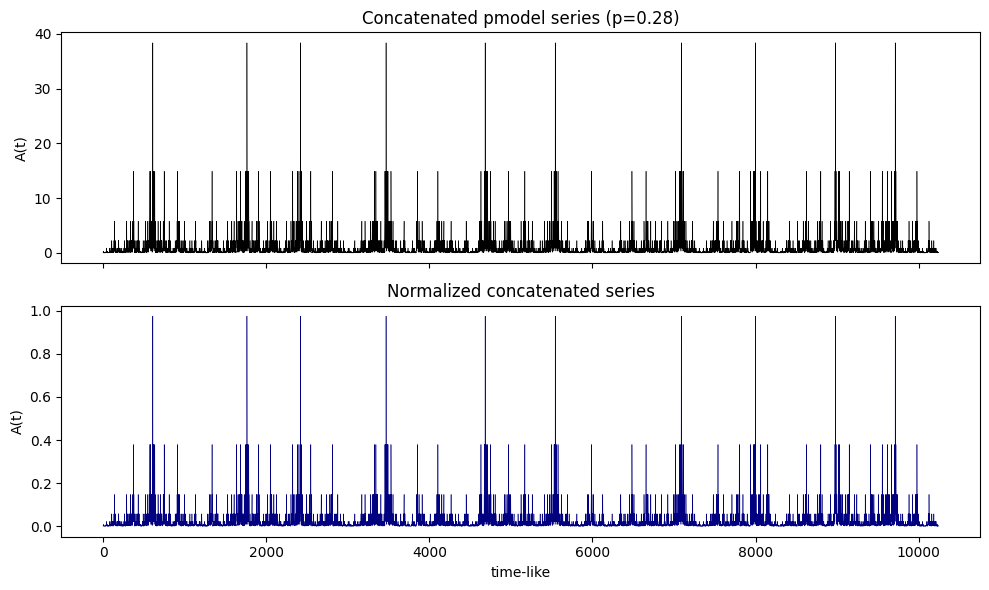

Output for 10 series, p = 0.28
A_max =  38.347599924474736
A_min =  0.013033054890961146
Mean =  1.0100000000000002
Sigma =  2.2066545336083507
3Sigma =  6.619963600825052
S_cr =  17.378161982504906


In [ ]:
# Parâmetros
num_series = 10
tamanho_serie = 1024
p = 0.28

# Geração
serie = gerar_series_concatenadas(num_series, tamanho_serie, p)

# Normalização
dfmax = max(serie)
dfn = serie / (dfmax + 1)

# Plotagem
fig, axs = plt.subplots(2, figsize=(10, 6))
axs[0].plot(serie, color='black', lw=0.4)
axs[0].set_title(f'Concatenated pmodel series (p={p})')

axs[1].plot(dfn, color='navy', lw=0.4)
axs[1].set_title('Normalized concatenated series')

for ax in axs:
    ax.set(xlabel='time-like', ylabel='A(t)')
    ax.label_outer()

plt.tight_layout()
plt.show()

# Estatísticas
print(f"Output for {num_series} series, p = {p}")
print("A_max = ", np.max(serie))
print("A_min = ", np.min(serie))
print("Mean = ", np.mean(serie))
print("Sigma = ", np.std(serie))
print("3Sigma = ", 3 * np.std(serie))
print("S_cr = ", np.max(serie) / np.std(serie))

In [ ]:
# Normalização
dfmax = np.max(serie)
dfn = serie / (dfmax + 1)

# Criando eixo x correspondente (tempo)
x = np.arange(len(serie))

# Criando os dicionários de dados
data = {
    'x': x,
    'df': serie
}

datan = {
    'x': x,
    'dfn': dfn
}

# Convertendo em DataFrames
df_data = pd.DataFrame(data)
df_datan = pd.DataFrame(datan)

# Salvando como CSV
df_data.to_csv('output_data.csv', index=False)
df_datan.to_csv('outputn_data.csv', index=False)

print("Séries concatenadas salvas como 'output_data.csv' e 'outputn_data.csv'")


Séries concatenadas salvas como 'output_data.csv' e 'outputn_data.csv'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

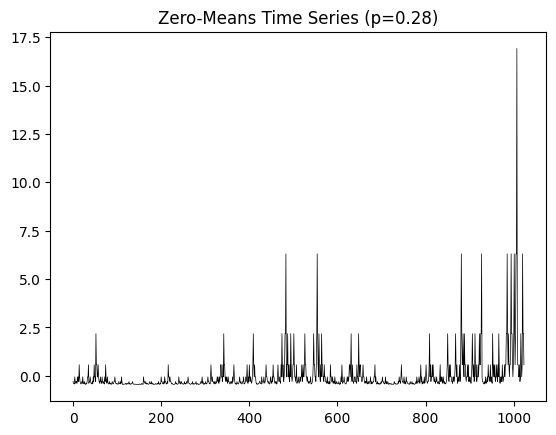

output for p = 0.28
A_max =  16.920455538375464
A_min =  -0.4518001934261932
Mean =  0.0
Sigma =  1.0
3Sigma =  3.0
S_cr =  16.920455538375464


In [ ]:
dfzm=(df - np.mean(df)) / np.std(df)
pyplot.plot(dfzm, color='black', lw=0.5)
pyplot.title("Zero-Means Time Series (p={})".format(p))
pyplot.show()

print("output for p = {}".format(p))

dfmax=max(dfzm)
print("A_max = ", dfmax)

dfmin=min(dfzm)
print("A_min = ", dfmin)

mean=np.mean(dfzm)
print("Mean = ", mean)

sigma=np.std(dfzm)
print("Sigma = ", sigma)

tsigma=3*sigma
print("3Sigma = ", tsigma)

Sigma_crit=(dfmax/sigma)
print("S_cr = ", Sigma_crit)

MATERIAL EXTRA- NÃO CONSIDERE PARA ESTA DISCIPLINA

Module: Shuffling the ZMTS via Cox-Box

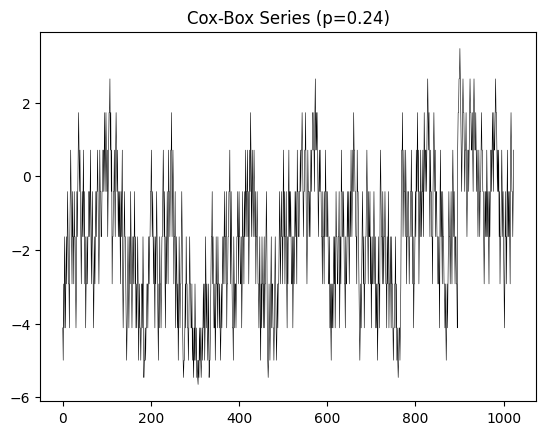

In [ ]:
from sklearn.utils import shuffle
from scipy import stats

fitted_data, fitted_lambda = stats.boxcox(df)

dfcox=fitted_data
pyplot.plot(dfcox, color='black', lw=0.4)
pyplot.title("Cox-Box Series (p={})".format(p))
pyplot.show()



Non-Gaussianity from Quantiles

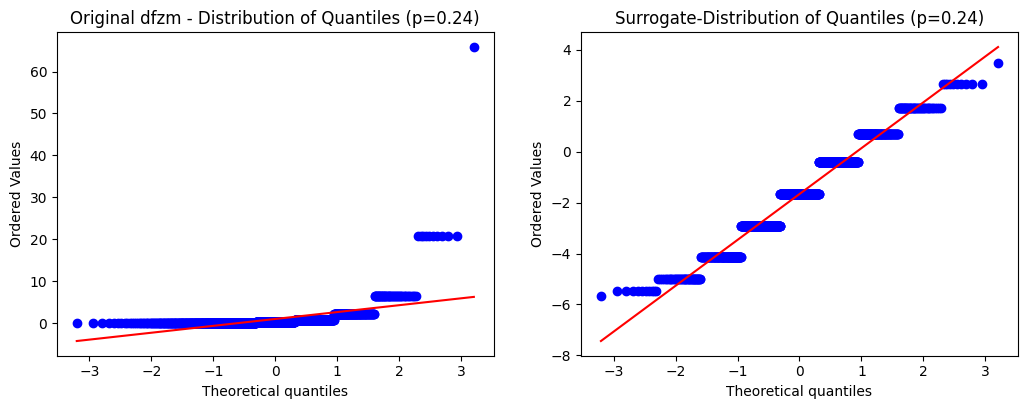

In [ ]:
#importing necessary libraries
import scipy.stats as stats
import pylab

plt.rcParams['figure.figsize'] = [12.4, 4.2]

plt.subplot(1, 2, 1)
stats.probplot(df,plot=pylab);
plt.title('Original dfzm - Distribution of Quantiles (p={})'.format(p));

plt.subplot(1, 2, 2)
stats.probplot(dfcox,plot=pylab);
plt.title('Surrogate-Distribution of Quantiles (p={})'.format(p));

plt.show()
print()

In [ ]:
print(dfzm)

[-0.29198225 -0.08115551 -0.38233657 ... -0.29198225 -0.38233657
 -0.42105984]


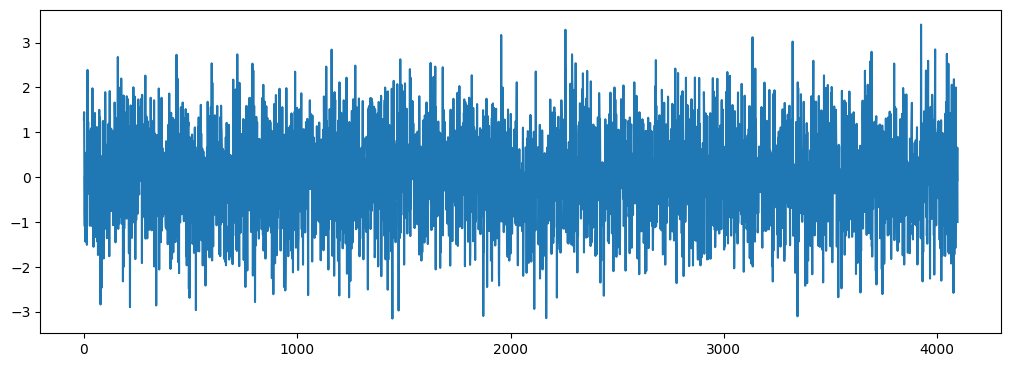

In [ ]:
#white noise generator
from random import gauss
from random import seed
from pandas import Series
from pandas.plotting import autocorrelation_plot
# seed random number generator
seed(1)
# create white noise series
series = [gauss(0.0, 1.0) for i in range(4096)]
wn = Series(series)

# line plot
wn.plot()
pyplot.show()

In [ ]:
from scipy.stats import entropy
y=abs(wn)
entropy(y, base=10)

3.4894689361638145

In [ ]:
from scipy.stats import entropy
y=abs(dfn)
entropy(y, base=10)

3.1921496006741705

Non-Gaussianity from PSD

(falta calculo do beta)

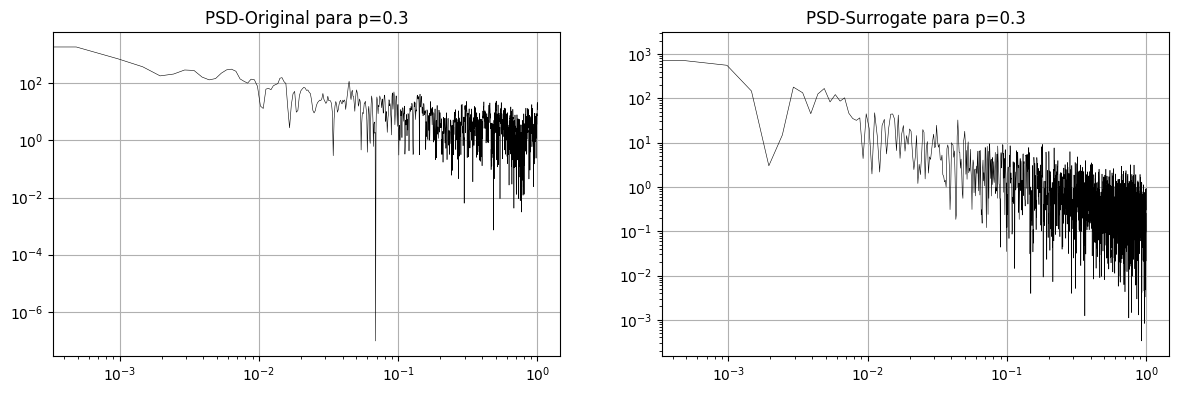

In [ ]:
#optionally plot the Power Spectral Density with Matplotlib
from matplotlib import mlab
from matplotlib import pylab as plt
import math
s, f = mlab.psd(df, NFFT=2**12)

plt.rcParams['figure.figsize'] = [14.4, 4.2]

plt.subplot(1, 2, 1)
plt.loglog(f,s,color='black', lw=0.40)
plt.title('PSD-Original para p={}'.format(p));
plt.grid(True)

s, f = mlab.psd(dfcox, NFFT=2**12)
plt.subplot(1, 2, 2)
plt.loglog(f,s,color='black', lw=0.40)
plt.title('PSD-Surrogate para p={}'.format(p));
#plt.loglog(f,s)
plt.grid(True)

plt.show()

In [ ]:
from scipy.stats import skew, kurtosis
A=dfzm
m=np.mean(A)
std=np.std(A)
s=skew(A)
k1=kurtosis(A)
k2=k1+3

print("mean =", m, end='\n')
print("std =", std, end='\n')
print("skewness =", s, end='\n')
print("Fisher Kurtosis =", k1, end='\n')
print("Pearson Kurtosis =", k2, end='\n\n')

#ss=s*s
#k=k2

statrib = (m, std, s, k2)
print("All set (Pearson Stat):")
for n in statrib:

    print(n, end=' , ')

print()

mean = -6.938893903907228e-18
std = 1.0
skewness = 31.512986080419683
Fisher Kurtosis = 1387.2660528066317
Pearson Kurtosis = 1390.2660528066317

All set (Pearson Stat):
-6.938893903907228e-18 , 1.0 , 31.512986080419683 , 1390.2660528066317 , 


# =====parte util até aqui====

# PSD-testando

Complementos Abaixo para Uso Futuro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

rng = np.random.RandomState(4096)
bc = PowerTransformer(method="box-cox")

X_trans_bc = bc.fit(X_train).transform(X_test)
    lmbda_bc = round(bc.lambdas_[0], 2)

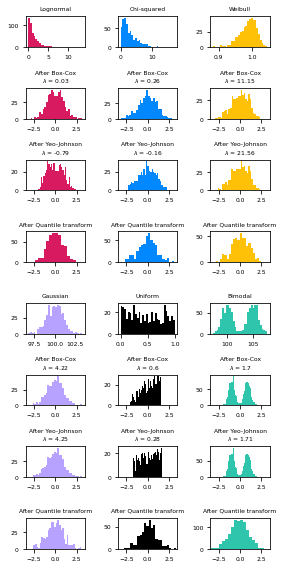

In [ ]:
# Author: Eric Chang <ericchang2017@u.northwestern.edu>
#         Nicolas Hug <contact@nicolas-hug.com>
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split


N_SAMPLES = 1000
FONT_SIZE = 6
BINS = 30


rng = np.random.RandomState(304)
bc = PowerTransformer(method="box-cox")
yj = PowerTransformer(method="yeo-johnson")
# n_quantiles is set to the training set size rather than the default value
# to avoid a warning being raised by this example
qt = QuantileTransformer(
    n_quantiles=500, output_distribution="normal", random_state=rng
)
size = (N_SAMPLES, 1)


# lognormal distribution
X_lognormal = rng.lognormal(size=size)

# chi-squared distribution
df = 3
X_chisq = rng.chisquare(df=df, size=size)

# weibull distribution
a = 50
X_weibull = rng.weibull(a=a, size=size)

# gaussian distribution
loc = 100
X_gaussian = rng.normal(loc=loc, size=size)

# uniform distribution
X_uniform = rng.uniform(low=0, high=1, size=size)

# bimodal distribution
loc_a, loc_b = 100, 105
X_a, X_b = rng.normal(loc=loc_a, size=size), rng.normal(loc=loc_b, size=size)
X_bimodal = np.concatenate([X_a, X_b], axis=0)


# create plots
distributions = [
    ("Lognormal", X_lognormal),
    ("Chi-squared", X_chisq),
    ("Weibull", X_weibull),
    ("Gaussian", X_gaussian),
    ("Uniform", X_uniform),
    ("Bimodal", X_bimodal),
]

colors = ["#D81B60", "#0188FF", "#FFC107", "#B7A2FF", "#000000", "#2EC5AC"]

fig, axes = plt.subplots(nrows=8, ncols=3, figsize=plt.figaspect(2))
axes = axes.flatten()
axes_idxs = [
    (0, 3, 6, 9),
    (1, 4, 7, 10),
    (2, 5, 8, 11),
    (12, 15, 18, 21),
    (13, 16, 19, 22),
    (14, 17, 20, 23),
]
axes_list = [(axes[i], axes[j], axes[k], axes[l]) for (i, j, k, l) in axes_idxs]


for distribution, color, axes in zip(distributions, colors, axes_list):
    name, X = distribution
    X_train, X_test = train_test_split(X, test_size=0.5)

    # perform power transforms and quantile transform
    X_trans_bc = bc.fit(X_train).transform(X_test)
    lmbda_bc = round(bc.lambdas_[0], 2)
    X_trans_yj = yj.fit(X_train).transform(X_test)
    lmbda_yj = round(yj.lambdas_[0], 2)
    X_trans_qt = qt.fit(X_train).transform(X_test)

    ax_original, ax_bc, ax_yj, ax_qt = axes

    ax_original.hist(X_train, color=color, bins=BINS)
    ax_original.set_title(name, fontsize=FONT_SIZE)
    ax_original.tick_params(axis="both", which="major", labelsize=FONT_SIZE)

    for ax, X_trans, meth_name, lmbda in zip(
        (ax_bc, ax_yj, ax_qt),
        (X_trans_bc, X_trans_yj, X_trans_qt),
        ("Box-Cox", "Yeo-Johnson", "Quantile transform"),
        (lmbda_bc, lmbda_yj, None),
    ):
        ax.hist(X_trans, color=color, bins=BINS)
        title = "After {}".format(meth_name)
        if lmbda is not None:
            title += "\n$\\lambda$ = {}".format(lmbda)
        ax.set_title(title, fontsize=FONT_SIZE)
        ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
        ax.set_xlim([-3.5, 3.5])


plt.tight_layout()
plt.show()